# Libraries

In [34]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

# Dataset

In [26]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = { i: s for s, i in stoi.items()}


In [35]:
# build the split dataset
# block_size or context length: how many characters do we take to predict the next one?

def build_dataset(words, block_size):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# Trigram data
TXtr, TYtr = build_dataset(words[:n1], 2)
TXdev, TYdev = build_dataset(words[n1:n2], 2)
TXte, TYte = build_dataset(words[n2:], 2)

# Bigram data
BXtr, BYtr = build_dataset(words[:n1], 1)
BXdev, BYdev = build_dataset(words[n1:n2], 1)
BXte, BYte = build_dataset(words[n2:], 1)

torch.Size([182437, 2]) torch.Size([182437])
torch.Size([22781, 2]) torch.Size([22781])
torch.Size([22928, 2]) torch.Size([22928])
torch.Size([182437, 1]) torch.Size([182437])
torch.Size([22781, 1]) torch.Size([22781])
torch.Size([22928, 1]) torch.Size([22928])


# Statistical implementation of the trigram model (E01, E02, E03)

In [100]:
Nt = torch.zeros((27, 27, 27), dtype = torch.int32)          # Size 27*27*27 because we have '.' along with the alphabets

for w in words:
    chs = ['.'] + list(w) + ['.']                     # The special character represents start and end of a word
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):                    # We have to iterate through 2 consecutive characters of word
        ix1 = stoi[ch1] 
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        Nt[ix1, ix2, ix3] += 1

In [101]:
# Smoothing (Regularisation)
alphaT = 1.0   # Laplace smoothing
Nt = Nt + alphaT

In [102]:
# THe probability matrix
Pt = Nt.float()
Pt /= Pt.sum(dim=2, keepdim=True)
i, j = 5, 10
print(Pt[i, j].sum())  # should be ~1.0


tensor(1.)


In [103]:
# evaluate loss

@torch.no_grad()
def trigram_loss(P, X, Y):
    # Extract previous characters
    x1 = X[:, 0]
    x2 = X[:, 1]

    # Get probabilities for the true next characters
    probs = Pt[x1, x2, Y]

    # Negative log-likelihood
    loss = -torch.log(probs).mean()

    return loss.item()

print("train loss:", trigram_loss(P, TXtr, TYtr))
print("dev loss  :", trigram_loss(P, TXdev, TYdev))
print("test loss :", trigram_loss(P, TXte, TYte))

train loss: 2.26054310798645
dev loss  : 2.2712888717651367
test loss : 2.2639031410217285


## E03
In this case, increasing the smoothing strength consistently increased both training and dev loss, indicating that the unsmoothed or lightly smoothed trigram already generalizes well. Therefore, simple add-1 smoothing was chosen as the best setting to avoid zero probabilities without introducing underfitting.

In [104]:
# Sampling from the model

for i in range(5):
    out = []
    ix, iy = 0, 0
    while True:
        p = Pt[ix, iy]          #This tells us: “Given current character ix, how likely is each next character?"
        # now p[k] = P(next_char = k | current_chars = ix, iy)
        ix = iy
        iy = torch.multinomial(p, num_samples=1, replacement=True).item()   #Randomly choose the next character index according to probabilities p
        out.append(itos[iy])
        if iy == 0:
            break
    print(''.join(out))

nan.
old.
ya.
wilidenkwarissitt.
el.


# NN implementation of the bigram model (E01, E02, E04, E05)

In classification with one-hot targets, cross-entropy loss reduces to the negative log-likelihood of the correct class; PyTorch’s cross_entropy simply implements this in a numerically stable and optimized way.

In [78]:
# initialize weight matrix
W = torch.randn((27, 27), requires_grad=True)

In [84]:
batch_size = 256
learning_rate = 0.1
steps = 100000
lambda_l2 = 0.01   # L2 regularization strength

for i in range(steps):

    # sample minibatch from TRAIN set
    ix = torch.randint(0, BXtr.shape[0], (batch_size,))
    Xb = BXtr[ix]   # input chars
    Yb = BYtr[ix]   # target chars
    Xb = Xb.squeeze(1)   # (32,1) -> (32,)

    # -------- forward pass --------
    # row indexing instead of one-hot
    logits = W[Xb]                 # (B, 27)

    # cross-entropy loss
    ce_loss = F.cross_entropy(logits, Yb)

    # L2 regularization term
    l2_loss = lambda_l2 * (W ** 2).mean()

    # total loss
    loss = ce_loss + l2_loss

    # -------- backward pass --------
    W.grad = None
    loss.backward()

    # -------- parameter update --------
    W.data += -100 * W.grad

print(loss.item())


2.557572603225708


In [86]:
# Evaluate losses

@torch.no_grad()
def evaluate_loss(X, Y):
    X = X.squeeze(1)     # same reason as in training
    logits = W[X]
    return F.cross_entropy(logits, Y).item()

print("train loss:", evaluate_loss(BXtr, BYtr))
print("dev loss  :", evaluate_loss(BXdev, BYdev))
print("test loss :", evaluate_loss(BXte, BYte))


train loss: 2.653958797454834
dev loss  : 2.6675546169281006
test loss : 2.658573627471924


In [87]:
# Sampling from the model

for _ in range(5):
    out = []
    ix = 0   # start token

    while True:
        logits = W[ix]                  # (27,)
        probs = F.softmax(logits, dim=0)

        ix = torch.multinomial(probs, 1, generator=g).item()
        out.append(itos[ix])

        if ix == 0:
            break

    print(''.join(out))

kaitann.
en.
torerdammn.
juay.
re.


## E01, E02

The trigram model achieves lower loss than the bigram model on both the dev and test sets, indicating that conditioning on a longer context improves predictive performance. However, the trigram also shows a slightly larger gap between training and dev loss, suggesting increased risk of overfitting. This highlights the tradeoff between model capacity and generalization, and motivates the use of a dev set to tune smoothing or regularization.

# Quadram with a MLP (E06)

In [61]:
# The dataset

Xtr, Ytr = build_dataset(words[:n1], 3)
Xdev, Ydev = build_dataset(words[n1:n2], 3)
Xte, Yte = build_dataset(words[n2:], 3)

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [62]:
# Setting up the parameters of our model

g = torch.Generator().manual_seed(69) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 100), generator=g)
b2 = torch.randn(100, generator=g)
W3 = torch.randn((100, 27), generator=g)
b3 = torch.randn(27, generator=g)

In [64]:
# This is just for utilising my GPU's parallelism

device = 'cuda'

C = C.to(device)
W1 = W1.to(device)
b1 = b1.to(device)
W2 = W2.to(device)
b2 = b2.to(device)
W3 = W3.to(device)
b3 = b3.to(device)

Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)
Xte = Xte.to(device)
Yte = Yte.to(device)

parameters = [C, W1, b1, W2, b2, W3, b3]


for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters)) # number of parameters in total

batch_size = 4096  # This is the size of batches we are taking for training at once

29297


In [66]:
# For visualization
lossi = []
stepi = []

In [72]:
# Training the model

for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device = device)
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
    logits = h2 @ W3 + b3 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
   
    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    # update
    for p in parameters: 
        p.data += -lr * p.grad


    # track stats
    # lri.append(lr)
    # lrei.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)

# Now if we work on the full dataset of over 200k entries then that will take a lot of time (really lot)
# So to address that, people usually train the model on mini-batches (A random part of the complete batch)
# With the mini-batch, we can run much more optimization loops and hence get lower loss but the quality of model i

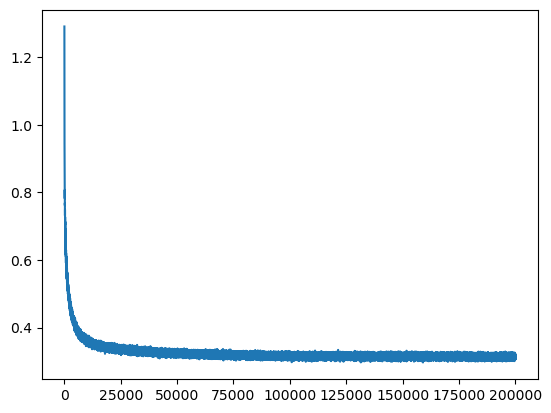

In [73]:
plt.plot(stepi, lossi)    # See training step v/s loss

In [74]:
# Training set loss

emb = C[Xtr] # (32, 3, 2)
h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
logits = h2 @ W3 + b3 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0614, device='cuda:0', grad_fn=<NllLossBackward0>)

In [75]:
# Dev set loss

emb = C[Xdev] # (32, 3, 2)
h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
logits = h2 @ W3 + b3 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1814, device='cuda:0', grad_fn=<NllLossBackward0>)

In [76]:
# Test set loss

emb = C[Xte] # (32, 3, 2)
h1 = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
logits = h2 @ W3 + b3 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1711, device='cuda:0', grad_fn=<NllLossBackward0>)

In [77]:
# sample from the model

for _ in range(5):

    out = []

    # context as a CUDA tensor
    context = torch.zeros((1, 3), dtype=torch.long, device=device)

    while True:
        # embedding lookup
        emb = C[context]                      # (1, block_size, d)
        h1 = torch.tanh(emb.view(1, -1) @ W1 + b1)
        h2 = torch.tanh(h1.view(-1, 200) @ W2 + b2)
        logits = h2 @ W3 + b3
        probs = F.softmax(logits, dim=1)

        # sample next token (already on GPU)
        ix = torch.multinomial(probs, num_samples=1)


        # update context (shift left, append ix)
        context = torch.cat([context[:, 1:], ix], dim=1)

        out.append(ix.item())  # only convert to Python here

        if ix.item() == 0:
            break

    print(''.join(itos[i] for i in out))

jaierseen.
flogh.
kehlowente.
hiwsin.
aley.
